In [ ]:
import pandas as pd
import numpy as np
init_seed = 42
np.random.seed(init_seed) # 用于numpy的随机数

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix,precision_recall_curve, roc_curve, auc, roc_auc_score
from sklearn import datasets, ensemble
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance

import xgboost as xgb
print(xgb.__version__)
from xgboost import XGBClassifier

import shap

import joblib

In [ ]:
############import datafile################################################
file_path1 = 'data/Label_data_n_258.csv'
data = pd.read_csv(file_path1)#, engine='openpyxl'
data

,VEC_HEA,Omega_HEA,Hmix_HEA,Electroneg_HEA,DeltaSize_HEA,Smix_HEA,Al+Cr,Cr/Al,Refractory_sum,NiCoCrAlFe_sum,...,T(C),Pdflist,Entry,Oxidation Time,Oxidation Weight Gain (mg/cm2),cluster,kn,n,kn_err,n_err
0,5.90000,0.0,-2.520000,0.048000,0.042854,2.702740,90.000000,0.0,10.000000,90.000000,...,1100,1,1,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN
1,5.90000,0.0,-2.520000,0.048000,0.042854,2.702740,90.000000,0.0,10.000000,90.000000,...,1100,1,1,18.000000,4.120390,0.0,NaN,NaN,NaN,NaN
2,5.90000,0.0,-2.520000,0.048000,0.042854,2.702740,90.000000,0.0,10.000000,90.000000,...,1100,1,1,36.000000,5.824330,0.0,0.946893,2.002759,0.000000,0.000000
3,5.90000,0.0,-2.520000,0.048000,0.042854,2.702740,90.000000,0.0,10.000000,90.000000,...,1100,1,1,54.000000,7.010000,0.0,1.060853,2.075546,0.074484,0.038911
4,5.90000,0.0,-2.520000,0.048000,0.042854,2.702740,90.000000,0.0,10.000000,90.000000,...,1100,1,1,72.000000,7.527830,0.0,1.629717,2.333774,0.548810,0.178756
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32755,5.41736,0.0,-26.549443,0.096331,0.074681,8.008781,56.694406,0.0,28.347203,56.694406,...,1200,786,5057,30.038109,21.229542,1.0,508.994565,3.153408,0.000000,0.000000
32756,5.41736,0.0,-26.549443,0.096331,0.074681,8.008781,56.694406,0.0,28.347203,56.694406,...,1200,786,5057,45.057164,25.642753,1.0,121.763157,2.663350,81.926711,0.216908
32757,5.41736,0.0,-26.549443,0.096331,0.074681,8.008781,56.694406,0.0,28.347203,56.694406,...,1200,786,5057,60.076218,29.871108,0.0,53.820536,2.391688,30.976757,0.178783
32758,5.41736,0.0,-26.549443,0.096331,0.074681,8.008781,56.694406,0.0,28.347203,56.694406,...,1200,786,5057,75.095273,34.652044,0.0,25.260857,2.147013,14.179034,0.168374


In [ ]:
###########check features################
# features = data.columns[0:246].tolist()
features = data.columns[0:258].tolist()+['Oxidation Time']
print(f'features are:{features}')
##########check data#######################
# data[features]
print(f'data contain Nan: {data[features].isna().any().any()}')
print(f'data contain inf: {np.isinf(np.isinf(data.iloc[:,:252].values).any()).any()}')

features are:['VEC_HEA', 'Omega_HEA', 'Hmix_HEA', 'Electroneg_HEA', 'DeltaSize_HEA', 'Smix_HEA', 'Al+Cr', 'Cr/Al', 'Refractory_sum', 'NiCoCrAlFe_sum', 'ECVF', 'WAPBR_ZrO2', 'WAPBR_TiO2', 'WAPBR_Ta2O5', 'WAPBR_Nb2O5', 'WAPBR_WO3', 'WAPBR_MoO3', 'WAPBR_V2O5', 'WAPBR_Fe2O3', 'WAPBR_Al2O3', 'WAPBR_Co3O4', 'WAPBR_Cr2O3', 'WAPBR_NiO', 'WAPBR', 'WAOR_ZrO2', 'WAOR_TiO2', 'WAOR_Ta2O5', 'WAOR_Nb2O5', 'WAOR_WO3', 'WAOR_MoO3', 'WAOR_V2O5', 'WAOR_Fe2O3', 'WAOR_Al2O3', 'WAOR_Co3O4', 'WAOR_Cr2O3', 'WAOR_NiO', 'WAOR', 'WOMR_ZrO2', 'WOMR_TiO2', 'WOMR_Ta2O5', 'WOMR_Nb2O5', 'WOMR_WO3', 'WOMR_MoO3', 'WOMR_V2O5', 'WOMR_Fe2O3', 'WOMR_Al2O3', 'WOMR_Co3O4', 'WOMR_Cr2O3', 'WOMR_NiO', 'WOMR', 'WSD_Ni', 'WSD_Co', 'WSD_Cr', 'WSD_Al', 'WSD_Fe', 'WSD_Nb', 'WSD_Ta', 'WSD_Ti', 'WSD_Zr', 'WSD_Mo', 'WSD_W', 'WSD_V', 'WSD', 'WID_V', 'WID_W', 'WID_Mo', 'WID_Zr', 'WID_Ti', 'WID_Ta', 'WID_Nb', 'WID_Fe', 'WID_Al', 'WID_Cr', 'WID_Co', 'WID_Ni', 'WID', 'WODS_Zr', 'WODS_Ti', 'WODS_Ta', 'WODS_Nb', 'WODS_W', 'WODS_Mo', 'WODS_V',

In [ ]:
#################################################################################
# Standardize the features
#################################################################################
# Columns to exclude
exclude_columns = ['cyc', 'dis', 'iso','N.1','Y.1']
##################Boolean to int################################# 
data[exclude_columns] = data[exclude_columns].astype(int)
########################################################################
# Remove elements in arrayA from arrayB
Numerical = list(set(features) - set(exclude_columns))
scaler = StandardScaler()
scaler.fit(data[Numerical])
###############################################################################################
data[Numerical] = scaler.transform(data[Numerical])
data

,VEC_HEA,Omega_HEA,Hmix_HEA,Electroneg_HEA,DeltaSize_HEA,Smix_HEA,Al+Cr,Cr/Al,Refractory_sum,NiCoCrAlFe_sum,...,T(C),Pdflist,Entry,Oxidation Time,Oxidation Weight Gain (mg/cm2),cluster,kn,n,kn_err,n_err
0,-0.485437,0.0,0.929520,-1.155079,-0.142336,-1.543374,4.116745,-0.102796,-0.488432,0.592892,...,0.761761,1,1,-0.259887,0.000000,0.0,NaN,NaN,NaN,NaN
1,-0.485437,0.0,0.929520,-1.155079,-0.142336,-1.543374,4.116745,-0.102796,-0.488432,0.592892,...,0.761761,1,1,-0.227408,4.120390,0.0,NaN,NaN,NaN,NaN
2,-0.485437,0.0,0.929520,-1.155079,-0.142336,-1.543374,4.116745,-0.102796,-0.488432,0.592892,...,0.761761,1,1,-0.194930,5.824330,0.0,0.946893,2.002759,0.000000,0.000000
3,-0.485437,0.0,0.929520,-1.155079,-0.142336,-1.543374,4.116745,-0.102796,-0.488432,0.592892,...,0.761761,1,1,-0.162451,7.010000,0.0,1.060853,2.075546,0.074484,0.038911
4,-0.485437,0.0,0.929520,-1.155079,-0.142336,-1.543374,4.116745,-0.102796,-0.488432,0.592892,...,0.761761,1,1,-0.129972,7.527830,0.0,1.629717,2.333774,0.548810,0.178756
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32755,-0.754256,0.0,-1.278191,-0.310916,0.860840,-0.057465,2.064229,-0.102796,0.039716,-0.295791,...,1.318022,786,5057,-0.205687,21.229542,1.0,508.994565,3.153408,0.000000,0.000000
32756,-0.754256,0.0,-1.278191,-0.310916,0.860840,-0.057465,2.064229,-0.102796,0.039716,-0.295791,...,1.318022,786,5057,-0.178587,25.642753,1.0,121.763157,2.663350,81.926711,0.216908
32757,-0.754256,0.0,-1.278191,-0.310916,0.860840,-0.057465,2.064229,-0.102796,0.039716,-0.295791,...,1.318022,786,5057,-0.151487,29.871108,0.0,53.820536,2.391688,30.976757,0.178783
32758,-0.754256,0.0,-1.278191,-0.310916,0.860840,-0.057465,2.064229,-0.102796,0.039716,-0.295791,...,1.318022,786,5057,-0.124387,34.652044,0.0,25.260857,2.147013,14.179034,0.168374


In [ ]:
#################################SMOTE#######################################
tem = data.copy()
tem = tem[~tem['cluster'].isna()]
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_smote, T_smote = sm.fit_resample(tem[features], tem['cluster'])
X_smote

,VEC_HEA,Omega_HEA,Hmix_HEA,Electroneg_HEA,DeltaSize_HEA,Smix_HEA,Al+Cr,Cr/Al,Refractory_sum,NiCoCrAlFe_sum,...,Ag,Au,pO2(mmHg),cyc,dis,iso,N.1,Y.1,T(C),Oxidation Time
0,-0.485437,0.0,0.929520,-1.155079,-0.142336,-1.543374,4.116745,-0.102796,-0.488432,0.592892,...,0.0,-0.018595,-0.115233,1,0,0,1,0,0.761761,-0.259887
1,-0.485437,0.0,0.929520,-1.155079,-0.142336,-1.543374,4.116745,-0.102796,-0.488432,0.592892,...,0.0,-0.018595,-0.115233,1,0,0,1,0,0.761761,-0.227408
2,-0.485437,0.0,0.929520,-1.155079,-0.142336,-1.543374,4.116745,-0.102796,-0.488432,0.592892,...,0.0,-0.018595,-0.115233,1,0,0,1,0,0.761761,-0.194930
3,-0.485437,0.0,0.929520,-1.155079,-0.142336,-1.543374,4.116745,-0.102796,-0.488432,0.592892,...,0.0,-0.018595,-0.115233,1,0,0,1,0,0.761761,-0.162451
4,-0.485437,0.0,0.929520,-1.155079,-0.142336,-1.543374,4.116745,-0.102796,-0.488432,0.592892,...,0.0,-0.018595,-0.115233,1,0,0,1,0,0.761761,-0.129972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53293,1.209938,0.0,0.653920,0.063198,-1.024149,-0.879811,0.165890,-0.102796,-0.776296,0.843892,...,0.0,-0.018595,-0.115233,0,1,0,0,1,0.205501,0.982847
53294,0.917600,0.0,-0.295237,0.433166,0.294578,0.340846,-0.181108,-0.097693,-0.551450,0.651305,...,0.0,-0.018595,-0.115233,0,1,0,1,0,1.318022,-0.164665
53295,0.998945,0.0,0.484098,0.280599,-0.281310,0.065052,0.243454,0.041810,-0.616189,0.674814,...,0.0,-0.018595,-0.115233,0,1,0,0,1,0.761761,0.532275
53296,0.795608,0.0,1.009415,-0.459847,-0.329197,0.336184,-0.320382,-0.102796,-0.776296,0.406113,...,0.0,-0.018595,-0.115233,0,0,1,0,1,0.205501,-0.135648


✅ Pearson correlation matrix saved to 'pearson_correlation.csv'


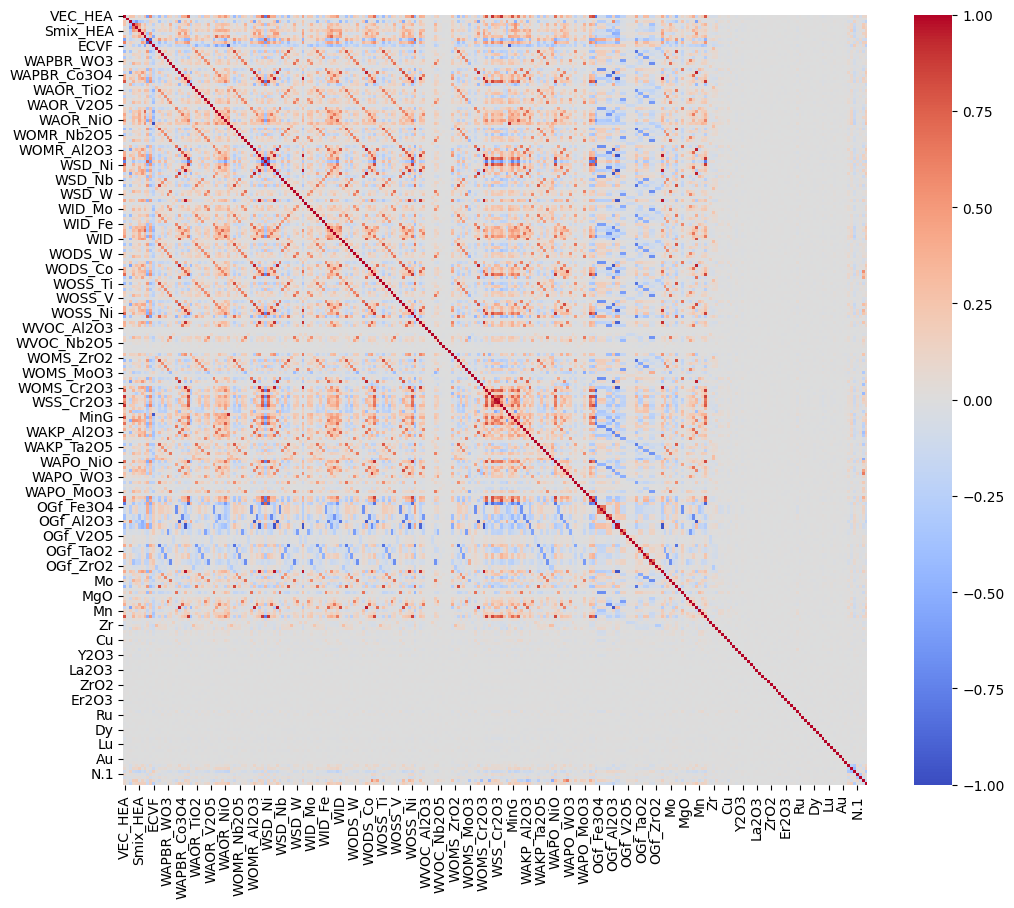

In [ ]:
##############################Compute Pearson Correlation##############################
temdf = data.copy()
temdf = temdf[features]
# Add small random noise to break ties
temdf = temdf + np.random.normal(0, 1e-10, temdf.shape)
# Calculate Spearman rank-order correlations
corr_matrix = temdf.corr(method='spearman')
#################save#############################################
corr_matrix.to_csv("data/pearson_correlation.csv")
print("✅ Pearson correlation matrix saved to 'pearson_correlation.csv'")
###################plot###################################################################
# Create a heatmap using Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)#,xticklabels= False, yticklabels= False , annot=True, fmt=".2f",annot_kws={"size":5}
##############################################################################################
# # Set a high DPI for better resolution (e.g., 300)
dpi = 2400
# Save the plot to a file with high resolution
plt.show()

In [ ]:
##############################Train simple model##############################
params = {
    'n_estimators': 100,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 1,
}
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
############model 1 class = 0####################
data_tem1 = data[data['cluster']==0]
X_train1 = data_tem1[features]
y_train1 = data_tem1['Oxidation Weight Gain (mg/cm2)']
####################
# Train RF regression model
model1 = ensemble.RandomForestRegressor(**params)#
model1.fit(
    X_train1, y_train1#,
)

RandomForestRegressor(max_features=1)

In [ ]:
############model 2 class != 0####################
data_tem2 = data[data['cluster']!=0]
X_train2 = data_tem2[features]
y_train2 = data_tem2['Oxidation Weight Gain (mg/cm2)']
####################
# Train RF regression model
model2 = ensemble.RandomForestRegressor(**params)#
model2.fit(
    X_train2, y_train2,
)

RandomForestRegressor(max_features=1)

In [ ]:
import shap
# Compute SHAP values for both models
explainer_1 = shap.Explainer(model1.predict, X_train1)#
explainer_2 = shap.Explainer(model2.predict, X_train2)#

shap_values_1 = explainer_1(X_train1).values
shap_values_2 = explainer_2(X_train2).values

PermutationExplainer explainer: 12044it [1:47:05,  1.87it/s]                           
PermutationExplainer explainer: 20718it [3:17:31,  1.75it/s]                             


In [ ]:
# joblib.dump(shap_values_1, 'data/shap_values_reg1_RF100n211.pkl')
# joblib.dump(shap_values_2, 'data/shap_values_reg2_RF100n211.pkl')

################################################################
shap_values_1 = joblib.load('data/shap_values_reg1_RF100n211.pkl')
shap_values_2 = joblib.load('data/shap_values_reg2_RF100n211.pkl')

In [ ]:
##################Compute mean absolute SHAP values (global feature importance)########################
shap_importance_1 = np.abs(shap_values_1).mean(axis=0)
shap_importance_2 = np.abs(shap_values_2).mean(axis=0)
#####################Weight SHAP values based on dataset size###############################
n1, n2 = len(X_train1), len(X_train2)
total_n = n1 + n2
weighted_reg_shap_importance = (shap_importance_1 * n1 + shap_importance_2 * n2) / total_n
# Convert results to a DataFrame
reg_shap_df = pd.DataFrame({
    'Feature': X_train1.columns,
    'Weighted SHAP Importance': weighted_reg_shap_importance
}).sort_values(by='Weighted SHAP Importance', ascending=False)
################# Convert to Pandas DataFrame for easy visualization######################################
feature_importance_df_1 = pd.DataFrame({'Feature': X_train1.columns, 'Importance': shap_importance_1})
feature_importance_df_2 = pd.DataFrame({'Feature': X_train2.columns, 'Importance': shap_importance_2})
#################Sort features by importance############################
feature_importance_df_1 = feature_importance_df_1.sort_values(by="Importance", ascending=False)
feature_importance_df_2 = feature_importance_df_2.sort_values(by="Importance", ascending=False)
###################Plot Feature Importance########################################################
# Plot CSVI total
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance_df_1["Feature"][:20], feature_importance_df_1["Importance"][:20], color='skyblue', label="PL")
ax.invert_yaxis()
plt.xlabel('Mean Absolute SHAP Value')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig("plot/regPL.png", dpi=800)  # You can change the filename and dpi
plt.legend()
plt.show()
# Plot CSVI total
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance_df_2["Feature"][:20], feature_importance_df_2["Importance"][:20], color='skyblue', label="!PL")
ax.invert_yaxis()
plt.xlabel('Mean Absolute SHAP Value')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig("plot/reg!PL.png", dpi=800)  # You can change the filename and dpi
plt.legend()
plt.show()
#################save#############################################
reg_shap_df.to_csv('data/reg SHAP importance_RF100n211.csv')
print("✅ SHAP important score saved to 'reg SHAP importance.csv'")

In [ ]:
import xgboost as xgb
##############################Train clf model##############################
params = {
    'n_estimators': 40,
    'max_depth': 10,
    'learning_rate': 0.5,
    'subsample': 0.9,
    'min_child_weight': 3,
}

model_clf = xgb.XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss',**params)
model_clf.fit(X_smote[features], T_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.5, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=40,
              n_jobs=None, num_class=3, num_parallel_tree=None, ...)

In [ ]:
############################SHAP analysis#############################
clf_explainer = shap.TreeExplainer(model_clf)
# Calculate SHAP values for a dataset (e.g., the training or test set)
clf_shap_values = clf_explainer.shap_values(X_smote[features])
print("SHAP Baseline (Expected Value):", clf_explainer.expected_value)

SHAP Baseline (Expected Value): [0.5934282, 0.6444904, -0.2849512]


In [ ]:
# joblib.dump(clf_shap_values, 'data/shap_values_clf_XG41593.pkl')
#################################################################
clf_shap_values = joblib.load('data/shap_values_clf_XG41593.pkl')

In [ ]:
############################################################################################################################################
importance_dfs ={}
# Get the mean absolute SHAP value for each feature, per class
for i in range(3):  # 3 classes
    # Calculate the mean absolute SHAP value for each feature for the current class
    mean_abs_shap = np.abs(clf_shap_values[:, :, i]).mean(axis=0)  # Shape will be (259,)
    # Create a DataFrame with feature names and their mean absolute SHAP values
    importance_df = pd.DataFrame({
        'Feature': features,  # Assuming 'features' is the list of feature names
        'Mean |SHAP|': mean_abs_shap
    })#.sort_values(by='Mean |SHAP|', ascending=False)
    #################################################
    tem = importance_df.sort_values(by='Mean |SHAP|', ascending=False)
    # Print the top 10 features for the current class
    print(f"Top features for Class {i}:")
    print(tem.head(10))
##################plot#####################################
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(tem["Feature"][:20], tem["Mean |SHAP|"][:20], color='skyblue', label="!PL")
    ax.invert_yaxis()
    plt.xlabel('Mean Absolute SHAP Value')
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    # plt.savefig(f"plot/clf{i}.png", dpi=800)  # You can change the filename and dpi
    plt.legend()
    plt.show()
###############################################################################################################
    importance_dfs[f'class:{i}'] = importance_df

In [ ]:
#####################Weight SHAP values based on dataset size###############################
m1, m2, m3 = (T_smote == 0.0).sum(),(T_smote == 1.0).sum(),(T_smote == 2.0).sum()
total_m = m1 + m2 + m3
weighted_clf_shap_importance = (importance_dfs['class:0']['Mean |SHAP|'] * m1 +
                                importance_dfs['class:1']['Mean |SHAP|'] * m2 + 
                                importance_dfs['class:2']['Mean |SHAP|'] * m3) / total_m

#############store clf df##############
clf_shap_df = pd.DataFrame({
    'Feature': importance_dfs['class:0']['Feature'],
    'Weighted SHAP Importance': weighted_clf_shap_importance
}).sort_values(by='Weighted SHAP Importance', ascending=False)
#################save#############################################
clf_shap_df.to_csv('data/clf SHAP importance_RF100n211.csv')
print("✅ SHAP important score saved to 'clf SHAP importance.csv'")

✅ SHAP important score saved to 'clf SHAP importance.csv'


In [ ]:
#############store total df##############
norm_clf_shap_importance = weighted_clf_shap_importance/weighted_clf_shap_importance.sum()
norm_reg_shap_importance = weighted_reg_shap_importance/weighted_reg_shap_importance.sum()

avg_shap_importance  = (norm_clf_shap_importance+norm_reg_shap_importance)/2
combined_score  = np.sqrt(norm_clf_shap_importance * norm_reg_shap_importance)
###########################################################
rank_reg = norm_clf_shap_importance.argsort().argsort()
rank_clf = norm_reg_shap_importance.argsort().argsort()
combined_rank = (rank_reg + rank_clf) / 2
################################################################
total_shap_df = pd.DataFrame({
    'Feature': importance_dfs['class:0']['Feature'],
    'avg SHAP Importance': avg_shap_importance,
    'Geometric Mean SHAP Importance': combined_score,
    'Rank SHAP Importance': combined_rank,
})#
#################save#############################################
total_shap_df.to_csv('data/total SHAP importance_RF100n211.csv')
print("✅ SHAP important score saved to 'SHAP importance.csv'")

✅ SHAP important score saved to 'SHAP importance.csv'


In [ ]:
#################plot#############################################
clf_shap_df= pd.read_csv('data/clf SHAP importance_RF100n211.csv')
reg_shap_df= pd.read_csv('data/reg SHAP importance_RF100n211.csv')
total_shap_df= pd.read_csv('data/total SHAP importance_RF100n211.csv')


In [ ]:
tem = total_shap_df.sort_values(by='avg SHAP Importance', ascending=False)
# avg SHAP Importance  Rank SHAP Importance  Geometric Mean SHAP Importance
# Plot CSVI total
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(tem['Feature'].iloc[:20], tem['avg SHAP Importance'].iloc[:20], color='skyblue')
ax.invert_yaxis()
plt.xlabel('CSVI')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("plot/CSVI.png", dpi=800)  # You can change the filename and dpi
plt.show()

In [ ]:
# Plot CSVI total
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(clf_shap_df['Feature'].iloc[:20], clf_shap_df['Weighted SHAP Importance'].iloc[:20], color='skyblue')
ax.invert_yaxis()
plt.xlabel('CSVI')
ax.grid(True, linestyle='--', alpha=0.6)
plt.title(r'CSVI$_{C,T}$(X,T)')
plt.tight_layout()
plt.savefig("plot/CSVIclf.png", dpi=800)  # You can change the filename and dpi
plt.show()

In [ ]:
# Plot CSVI total
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(reg_shap_df['Feature'].iloc[:20], reg_shap_df['Weighted SHAP Importance'].iloc[:20], color='skyblue')
ax.invert_yaxis()
plt.xlabel('CSVI')
ax.grid(True, linestyle='--', alpha=0.6)
plt.title(r'CSVI$_{C,Y}$(X,Y|T)')
plt.tight_layout()
plt.savefig("plot/CSVIreg.png", dpi=800)  # You can change the filename and dpi
plt.show()